## About

**1.** We perform exploratory data analysis. This includes creating statistical summaries and charts, testing for anomalies, checking for correlations and other relations between variables, and other EDA elements.

**2.** We perform statistical inference. This includes defining the target population, forming multiple statistical hypotheses and constructing confidence intervals, setting the significance levels, conducting various tests for these hypotheses.

**3.** Apply various machine learning models to predict the "price" column using all other features. This should include hyperparameter tuning, model ensembling, the analysis of model selection, and other methods.

**4.** Deploy the machine learning model. Choose the best performing model and deploy it. You are free to choose any deployment option that you like - you need to containerize the model as a service application and deploy it to Google Cloud Platform so that the model output could be callable through HTTP request.

**Dataset:**

- [Real Estate Listings in Portugal](https://www.kaggle.com/datasets/luvathoms/portugal-real-estate-2024)

**Context:**

This weekly updated dataset contains the more than 100k real asking prices for real estate properties listed on Portuguese real estate websites. The data was legally and ethically scraped from several online platforms, ensuring compliance with the platforms' terms and conditions.

**Goal:**

The primary objective is to create a machine learning model, which could predict the price for a given house. The pricing predictions API will be automated with events driven pipeline when new offer is being uploaded to any real estate system. If the price prediction of real estate will be lower than estimation, brokers will contact the owner immediately in order to buy it.

## Imports

In [1]:
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
    cross_val_score,
    cross_validate,
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scikit_posthocs import posthoc_dunn
import optuna
import shap

from consts import LISTINGS_DATASET

sns.set_style("whitegrid")
warnings.filterwarnings(
    "ignore",
    message="Found unknown categories",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
)

## Load the dataset and Overview

We use a copy of our dataset to leave the original one untouched.

In [2]:
shutil.copy(LISTINGS_DATASET, "datasets/portugal_listings_copy.csv")
df = pd.read_csv("datasets/portugal_listings_copy.csv", low_memory=False)
df.head()

,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,0.0
4,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   GrossArea              27638 non-null   float64
 7   TotalArea              127153 non-null  float64
 8   Parking                135342 non-null  float64
 9   HasParking             68215 non-null   object 
 10  Floor                  27929 non-null   object 
 11  ConstructionYear       88021 non-null   float64
 12  EnergyEfficiencyLevel  67289 non-null   object 
 13  PublishDate            29239 non-null   object 
 14  Garage                 67289 non-nul

We see that the dataset consists of 135 536 listings and 25 columns. Many columns have significant amounts of missing data, and several have mixed data types.

In [4]:
df.describe().round(2)

,Price,GrossArea,TotalArea,Parking,ConstructionYear,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
count,1.352360e+05,27638.00,1.271530e+05,135342.00,88021.00,73244.00,47041.00,57256.00,104952.00,3.958300e+04,26617.00,128700.00
mean,3.681375e+05,2789.73,5.140780e+05,0.55,1989.30,3.23,2.67,0.43,1403.04,5.636939e+04,3086.62,1.54
std,3.804044e+06,115366.98,1.722937e+08,0.84,26.68,10.52,1.79,1.02,34745.97,5.208474e+06,118513.70,1.76
min,1.000000e+00,-7.00,-7.196067e+06,0.00,1900.00,0.00,0.00,-15.00,0.00,0.000000e+00,-1.00,-13.00
25%,8.400000e+04,100.00,9.100000e+01,0.00,1973.00,2.00,2.00,0.00,80.00,2.580000e+02,104.57,0.00
50%,2.100000e+05,164.00,1.590000e+02,0.00,1994.00,3.00,3.00,0.00,118.00,6.790000e+02,168.00,1.00
75%,3.950000e+05,294.00,5.000000e+02,1.00,2009.00,4.00,3.00,1.00,204.00,2.890000e+03,300.00,2.00
max,1.380000e+09,12750000.00,6.142007e+10,3.00,2025.00,2751.00,21.00,59.00,5429000.00,9.923010e+08,12750000.00,131.00


We get a brief overview about each column above.

## Data Cleaning

### Missing values

In [5]:
(df.isna().mean() * 100).sort_values(ascending=False).round(1)

ConservationStatus       85.8
BuiltArea                80.4
GrossArea                79.6
Floor                    79.4
PublishDate              78.4
LotSize                  70.8
NumberOfBedrooms         65.3
NumberOfWC               57.8
EnergyEfficiencyLevel    50.4
ElectricCarsCharging     50.4
Garage                   50.4
HasParking               49.7
TotalRooms               46.0
ConstructionYear         35.1
LivingArea               22.6
TotalArea                 6.2
NumberOfBathrooms         5.0
Price                     0.2
Parking                   0.1
Elevator                  0.0
Type                      0.0
EnergyCertificate         0.0
Town                      0.0
District                  0.0
City                      0.0
dtype: float64

We observe severe missingness in many columns.

**Decision:** We drop all columns with more than 40 % missing values because imputing so much data would introduce heavy bias. We also drop `City` (275 unique values) and `Town` (2 263 unique values) to avoid extremely high-dimensional one-hot encoding; `District` (27 categories) already captures the geographic signal at a reasonable level.

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(1)
high_missing = missing_pct[missing_pct > 40].index.tolist()
print("Dropping high-missing columns:", high_missing)
df.drop(columns=high_missing, inplace=True)

df.drop(columns=["City", "Town"], inplace=True)

print(f"\nRemaining columns {list(df.columns)}")

Dropping high-missing columns: ['ConservationStatus', 'BuiltArea', 'GrossArea', 'Floor', 'PublishDate', 'LotSize', 'NumberOfBedrooms', 'NumberOfWC', 'EnergyEfficiencyLevel', 'ElectricCarsCharging', 'Garage', 'HasParking', 'TotalRooms']

Remaining columns ['Price', 'District', 'Type', 'EnergyCertificate', 'TotalArea', 'Parking', 'ConstructionYear', 'Elevator', 'LivingArea', 'NumberOfBathrooms']


### Handling data types and invalid values

**Price:** We drop rows where `Price` is missing or non-positive - these are unusable as training labels.

**Elevator:** The raw column contains a mix of string (`"True"/"False"`) and boolean values. We map them to numeric `1`/`0`; anything else becomes `NaN` (handled later by the imputer).

**Type:** We keep only the 7 most common property types, which cover the majority of the data. Rare types would create sparse one-hot columns with almost no signal - later in the modeling part.

In [7]:
print(f"Rows before price filter: {len(df)}")
df = df.dropna(subset=["Price"])
df = df[df["Price"] > 0]
print(f"Rows after price filter:  {len(df)}")

df["Elevator"] = df["Elevator"].astype(str).map({"True": 1, "False": 0})

top_types = df["Type"].value_counts().head(7).index.tolist()
print(f"\nKept property types: {top_types}")
df = df[df["Type"].isin(top_types)]
print(f"Rows after type filter: {len(df)}")

Rows before price filter: 135536
Rows after price filter:  135236

Kept property types: ['Apartment', 'House', 'Land', 'Store', 'Farm', 'Building', 'Transfer of lease']
Rows after type filter: 129034


### Checking for duplicates

In [8]:
print(df.duplicated().any())

df_t = df.T
print(df_t.duplicated().any())

True
False


We observe duplicate rows and no duplicate columns.

**Decision:** We drop duplicate rows. In a scraped real estate dataset, exact duplicates are most likely re-crawled listings of the same property at the same price. Keeping them would artificially inflate the training set with redundant information and bias the model toward properties that happen to appear multiple times.

In [9]:
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Rows after dropping duplicates: {len(df)}")

Duplicate rows: 26921
Rows after dropping duplicates: 102113


### Handling outliers in Price

In [10]:
price_millions = df["Price"] / 1_000_000

print(f"Price range: €{price_millions.min():,.2f}M – €{price_millions.max():,.2f}M")
print(f"Median: €{price_millions.median():,.2f}M")
print(f"99th percentile: €{price_millions.quantile(0.99):,.2f}M")
print(f"1st percentile: €{price_millions.quantile(0.01):,.2f}M")

Price range: €0.00M – €1,380.00M
Median: €0.22M
99th percentile: €2.70M
1st percentile: €0.01M


The price distribution is extremely right-skewed with values ranging from near zero to over a billion euros. Many extreme values are likely data errors or commercial/institutional listings - as i looked through listings in Portugal on the web, I couldnt find a single one that costs a couple of euros and neither one above a billion.

**Decision:** Filtering out prices outside the 1st–99th percentile range seems reasonable here. Unlike clipping (which would replace extremes with the boundary value and create artificial density spikes at the edges), filtering removes these rows entirely. This is the better choice here because extreme prices likely represent data errors or fundamentally different property types (e.g., commercial portfolios) that our model should not learn from.

In [11]:
q_low, q_high = df["Price"].quantile(0.01), df["Price"].quantile(0.99)
print(f"Clipping to [{q_low:,.0f}, {q_high:,.0f}]")

df = df[(df["Price"] >= q_low) & (df["Price"] <= q_high)].reset_index(drop=True)
print(f"Rows after outlier removal: {len(df)}")

Clipping to [6,500, 2,700,000]
Rows after outlier removal: 100151


### Handling outliers in area columns

Unlike Price (where we removed entire rows), here we set extreme area values to `NaN` rather than dropping the row. The reason: the rest of that row's data (Price, District, Type, etc.) is still valid and useful for training — we only distrust the area measurement. The `NaN` will later be filled by median imputation in the preprocessing pipeline.

In [12]:
for col in ["TotalArea", "LivingArea"]:
    neg = (df[col] < 0).sum()
    if neg:
        df.loc[df[col] < 0, col] = np.nan
        print(f"{col}: set {neg} negative values to NaN")

    q99 = df[col].quantile(0.99)
    before = df[col].notna().sum()
    df.loc[df[col] > q99, col] = np.nan
    print(f"{col}: capped values above {q99:,.0f} to NaN")

TotalArea: set 7 negative values to NaN
TotalArea: capped values above 45,160 to NaN
LivingArea: capped values above 14,500 to NaN


### Cleaned dataset overview

In [13]:
print(f"Shape: {df.shape}")
print(f"\nMissing values (%):")
print((df.isna().mean() * 100).round(1))
print(f"\nData types:")
print(df.dtypes)

Shape: (100151, 10)

Missing values (%):
Price                 0.0
District              0.0
Type                  0.0
EnergyCertificate     0.0
TotalArea             5.2
Parking               0.1
ConstructionYear     29.5
Elevator              0.0
LivingArea           19.5
NumberOfBathrooms     4.5
dtype: float64

Data types:
Price                float64
District              object
Type                  object
EnergyCertificate     object
TotalArea            float64
Parking              float64
ConstructionYear     float64
Elevator             float64
LivingArea           float64
NumberOfBathrooms    float64
dtype: object


## EDA

Before modeling, we check distributions, outliers/anomalies, and relationships. This helps us pick appropriate tests/models (e.g., whether a t-test is appropriate, whether scaling matters, whether extreme values dominate).

We start by taking a look at our **target variable - Price**.

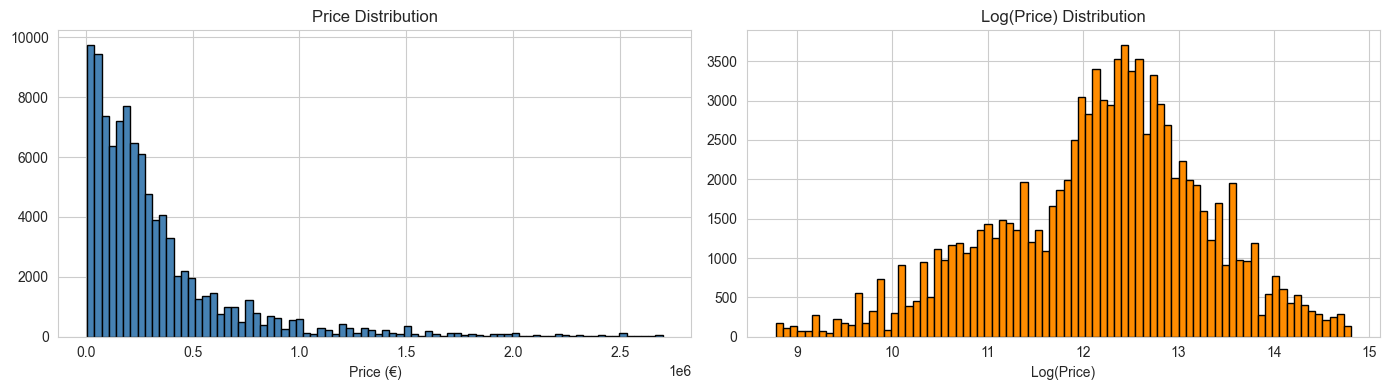

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["Price"], bins=80, edgecolor="black", color="steelblue")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (€)")

axes[1].hist(np.log1p(df["Price"]), bins=80, edgecolor="black", color="darkorange")
axes[1].set_title("Log(Price) Distribution")
axes[1].set_xlabel("Log(Price)")

plt.tight_layout()
plt.show()

The raw price is heavily right-skewed - meaning that the vast majority of prices are relatively low, but a handful of very expensive outliers pull the average up. After log-transformation, it becomes much more symmetric and closer to a normal distribution. We will use `log(Price)` as our target for modeling, which helps linear models and reduces the influence of high-priced listings.

### Numerical feature distributions

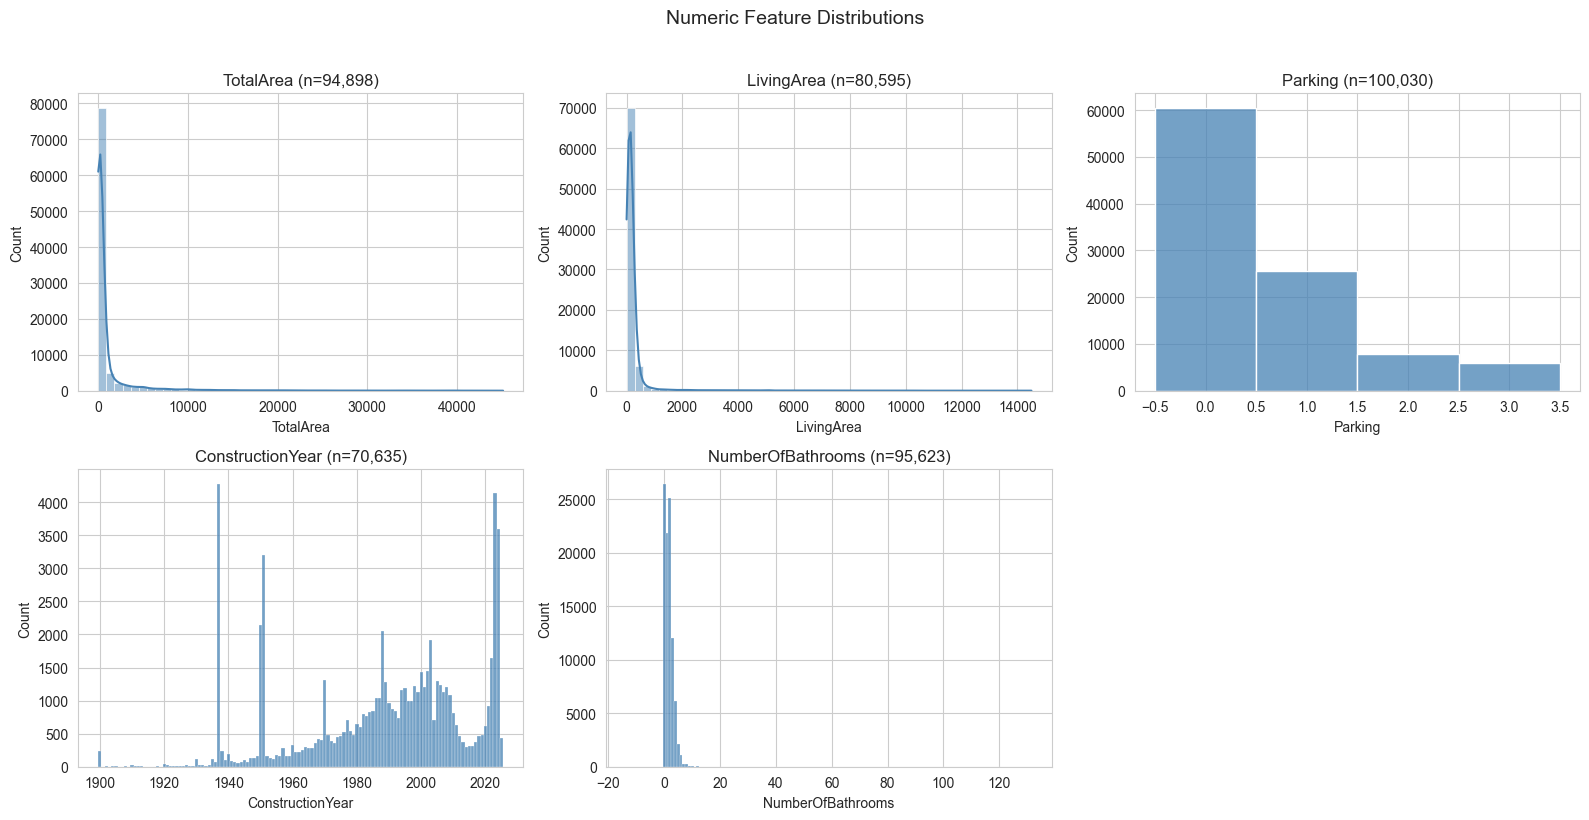

In [15]:
num_cols = [
    "TotalArea",
    "LivingArea",
    "Parking",
    "ConstructionYear",
    "NumberOfBathrooms",
]
discrete_cols = ["Parking", "NumberOfBathrooms", "ConstructionYear"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    if col in discrete_cols:
        sns.histplot(data, discrete=True, ax=axes[i], color="steelblue")
    else:
        sns.histplot(data, bins=50, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} (n={len(data):,})")
    axes[i].set_xlabel(col)

axes[-1].axis("off")
plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **TotalArea** and **LivingArea** are right-skewed, with most properties under 500 m². These two features will likely be highly correlated (both measure property size) - we investigate this in the multicollinearity section below.
- **Parking** is mostly 0–2 spaces; a discrete, low-cardinality feature.
- **ConstructionYear** spans a wide range, with most properties built after 1980.
- **NumberOfBathrooms** is concentrated at 1–3.

### Categorical feature distributions

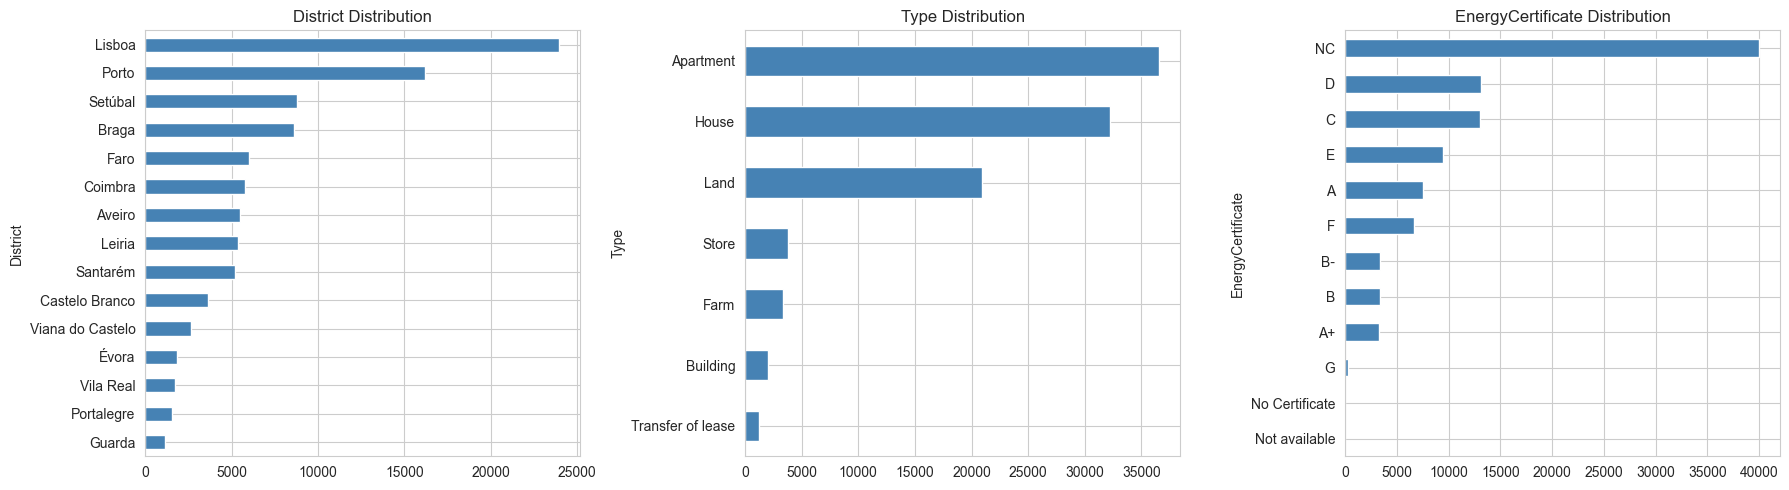

In [16]:
cat_cols = ["District", "Type", "EnergyCertificate"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(15)
    counts.plot.barh(ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} Distribution")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

**Observations:**

- Most properties are in Lisboa and Porto
- The majority of offerings are apartments, houses or land
- The majority of offerings have NC concerning the Energy Certificate - since those are the Portuguese energy certification standards NC refers to not communicated or not classified.

### Price by categorical features

Now we want to specifically check for the relationship of the categorical features against our target variable, the price.

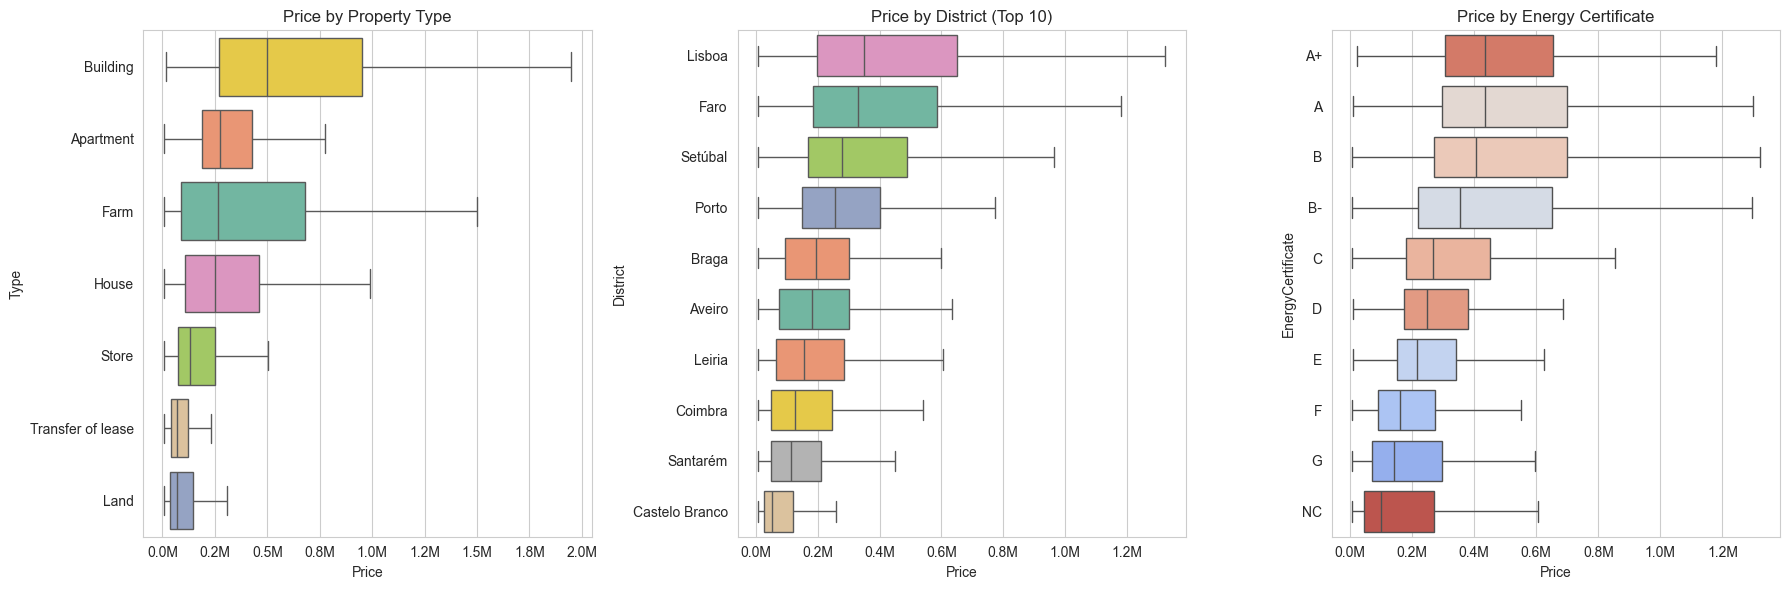

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

order_type = df.groupby("Type")["Price"].median().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    y="Type",
    x="Price",
    order=order_type,
    ax=axes[0],
    showfliers=False,
    hue="Type",
    palette="Set2",
    legend=False,
)
axes[0].set_title("Price by Property Type")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

top_districts = df["District"].value_counts().head(10).index
df_top = df[df["District"].isin(top_districts)]
order_dist = (
    df_top.groupby("District")["Price"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df_top,
    y="District",
    x="Price",
    order=order_dist,
    ax=axes[1],
    showfliers=False,
    hue="District",
    palette="Set2",
    legend=False,
)
axes[1].set_title("Price by District (Top 10)")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

order_ec = ["A+", "A", "B", "B-", "C", "D", "E", "F", "G", "NC"]
valid_ec = [e for e in order_ec if e in df["EnergyCertificate"].unique()]
sns.boxplot(
    data=df,
    y="EnergyCertificate",
    x="Price",
    order=valid_ec,
    ax=axes[2],
    showfliers=False,
    hue="EnergyCertificate",
    palette="coolwarm_r",
    legend=False,
)
axes[2].set_title("Price by Energy Certificate")
axes[2].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

**Observations:**
- **Property Type:** Buildings and Farms command the highest median prices; Stores, land and transfer of lease are the lowest among the selected types.
- **District:** Lisboa and Faro have the highest median prices; northern districts tend to be lower.
- **Energy Certificate:** Higher efficiency ratings (A+, A) tend to be associated with higher prices.

### Correlation analysis

We compute both **Pearson** and **Spearman** correlation matrices:

- **Pearson** measures *linear* relationships — it assumes both variables change at a constant rate relative to each other.
- **Spearman** measures *monotonic* relationships — it only asks "when one goes up, does the other go up (or down)?" It works on ranks, so it captures non-linear relationships as long as the direction is consistent.

If Spearman is noticeably higher than Pearson for a pair, the relationship is real but non-linear (e.g., price grows faster than area at the high end). This matters for model choice: linear models only exploit Pearson-type relationships, while tree-based models capture any monotonic pattern.

We apply the analysis on the numerical features. By comparing both coefficients now, we set expectations for modeling: if key relationships turn out non-linear, tree-based models (which handle this natively) should outperform plain linear models — and log-transforming the target may help linearize the price side of the relationship.

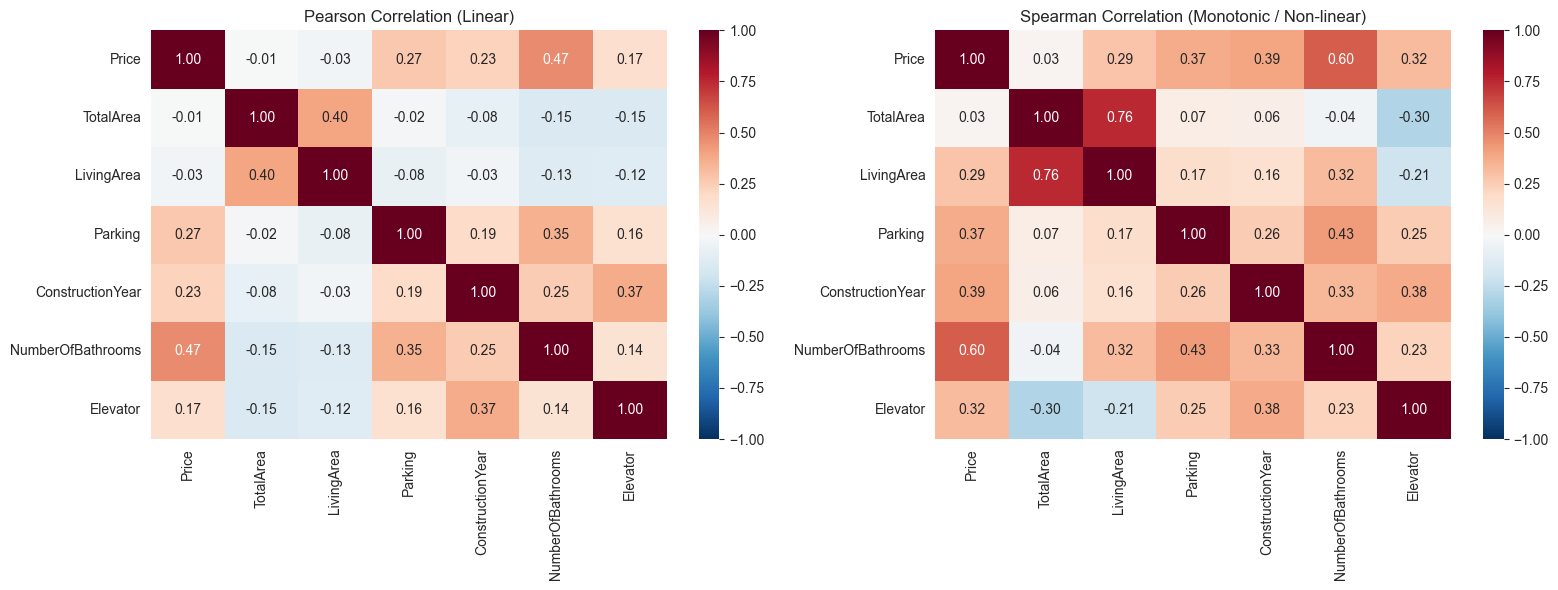

In [18]:
num_data = df[
    [
        "Price",
        "TotalArea",
        "LivingArea",
        "Parking",
        "ConstructionYear",
        "NumberOfBathrooms",
        "Elevator",
    ]
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pearson_corr = num_data.corr(method="pearson")
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=axes[0],
    vmin=-1,
    vmax=1,
)
axes[0].set_title("Pearson Correlation (Linear)")

spearman_corr = num_data.corr(method="spearman")
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=axes[1],
    vmin=-1,
    vmax=1,
)
axes[1].set_title("Spearman Correlation (Monotonic / Non-linear)")

plt.tight_layout()
plt.show()

**Observations:**

Correlation with the target (Price):
- **NumberOfBathrooms** is the strongest numeric predictor (Spearman ρ ≈ 0.60, Pearson ≈ 0.47). The gap confirms a non-linear relationship — more bathrooms means higher prices, but not at a constant rate.
- **TotalArea** and **LivingArea** show Spearman ρ ≈ 0.29 but Pearson near zero (-0.01 to -0.03). A linear model would see almost no signal here, while a tree-based model would pick up the monotonic trend that larger properties cost more.
- **ConstructionYear**, **Parking**, and **Elevator** all show moderate Spearman values (0.32–0.39) with lower Pearson values, following the same non-linear pattern.

Correlation between features (multicollinearity signals):
- **TotalArea and LivingArea** is the main concern — Spearman ρ ≈ 0.76, Pearson ≈ 0.40. Both measure property size and carry largely redundant information. We investigate this with VIF below.
- **NumberOfBathrooms and Parking** (Spearman ≈ 0.43, Pearson ≈ 0.35) — both tend to increase with property size and value.
- **ConstructionYear and Elevator** (Spearman ≈ 0.38, Pearson ≈ 0.37) — newer buildings are more likely to have elevators. This pair is notably close to linear (Pearson ≈ Spearman).
- **Elevator and TotalArea** (Spearman ≈ -0.30) — a negative association: properties with elevators tend to have smaller total area than houses without.
- Several other pairs show moderate overlap (0.25–0.35), mostly reflecting that size-related features (bathrooms, area, parking) tend to move together. None are strong enough to be alarming individually, but together they reinforce why multicollinearity deserves a closer look with VIF.

### Multicollinearity Check (VIF)

Now we specifically check how much the *features correlate with each other* — **multicollinearity**. If two features carry essentially the same information (e.g., TotalArea and LivingArea both measure property size), one of them is redundant — it adds noise without adding new signal.

In [19]:
vif_cols = [
    "TotalArea",
    "LivingArea",
    "Parking",
    "ConstructionYear",
    "NumberOfBathrooms",
    "Elevator",
]
vif_data = df[vif_cols].dropna()

vif_df = (
    pd.DataFrame(
        {
            "Feature": vif_cols,
            "VIF": [
                variance_inflation_factor(vif_data.values, i)
                for i in range(len(vif_cols))
            ],
        }
    )
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("Variance Inflation Factors:")
display(vif_df.round(2))

Variance Inflation Factors:


,Feature,VIF
0,ConstructionYear,3.43
1,NumberOfBathrooms,2.83
2,Parking,1.75
3,Elevator,1.42
4,LivingArea,1.19
5,TotalArea,1.18


**Decision:** VIF < 5 indicates low multicollinearity, no need to drop variables here.

### EDA Summary

- Price is heavily right-skewed — we use log(Price) as target for modeling.
- Lisboa and Porto dominate the dataset; most listings are apartments.
- Higher energy certificates (A+, A) tend to have higher prices; most listings have NC (not classified).
- NumberOfBathrooms is the strongest numeric predictor of price (Spearman ρ ≈ 0.60).
- TotalArea and LivingArea are highly correlated, but VIF values remain acceptable — no features dropped for multicollinearity.

## Statistical Inference

**Target population:** Properties listed for sale on Portuguese real estate platforms.

In [20]:
print(f"Target population size: {len(df)}")

Target population size: 100151


We are now going to check whether some of the tendencies observed in EDA are statistically significant.

Therefore we're going to iteratively raise and test hypotheses.

Since our previous checks showed that our data is heavily skewed and not normally distributed, the mean is a misleading metric. Therefore, we use the non-parametric Mann-Whitney U test to compare the rank distributions, which is best represented practically by the median - we therefore are going to use this metric to construct the confidence intervals.

We now test whether some of the tendencies observed in EDA are statistically significant. We use **Mann-Whitney U tests** for comparing price distributions (since price is not normally distributed) and **Kruskal Wallis H-test** for price comparisons across groups.

To be completely rigorous, we would test for normality within each group separately (e.g. via **Shapiro-Wilk**). However, since real estate prices are inherently right-skewed and our overall price distribution already showed clear non-normality, subgroups of the same variable will not suddenly become normal. Additionally, with sample sizes of thousands to tens of thousands per group, formal normality tests like Shapiro-Wilk become overly sensitive and reject normality for even trivial deviations. Using non-parametric tests throughout is therefore the safer and more appropriate choice.

### Hypothesis 1: Price differs between apartments and houses

Nullhypothesis: The price distribution of apartments is the same as that of houses.  
Alternative Hypothesis: The price distributions differ.  
Significance level: 0.05  
Test: Mann-Whitney U test

Median price (Apartment): €275,000
Median price (House): €250,000
Mann-Whitney U-test: U=671,102,413, p=2.748e-217


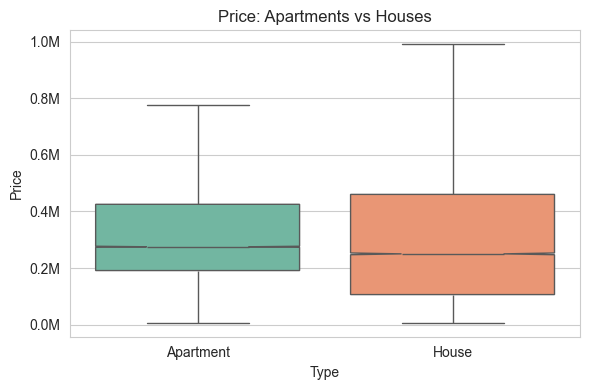

In [21]:
price_apt = df.loc[df["Type"] == "Apartment", "Price"]
price_house = df.loc[df["Type"] == "House", "Price"]

stat, pval = stats.mannwhitneyu(price_apt, price_house, alternative="two-sided")

print(f"Median price (Apartment): €{price_apt.median():,.0f}")
print(f"Median price (House): €{price_house.median():,.0f}")
print(f"Mann-Whitney U-test: U={stat:,.0f}, p={pval:.3e}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=df[df["Type"].isin(["Apartment", "House"])],
    x="Type",
    y="Price",
    showfliers=False,
    hue="Type",
    palette="Set2",
    legend=False,
    notch=True,
    ax=ax,
)
ax.set_title("Price: Apartments vs Houses")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

The p value is well below our significance level, which means that we reject our Nullhypothesis and conclude the alternative one. The statistic significance gets supported by non overlapping confidence intervals, which we can see above.

### Hypothesis 2: Properties in Lisboa are more expensive than in Porto

Nullhypothesis: The price distribution is the same in Lisboa and Porto.  
Alternative Hypothesis: Lisboa prices are higher.  
Significance level: 0.05  
Test: Mann-Whitney U test

Median price (Lisboa): €350,000
Median price (Porto):  €255,900
Mann-Whitney U-test: U=239,090,972, p=0.000e+00


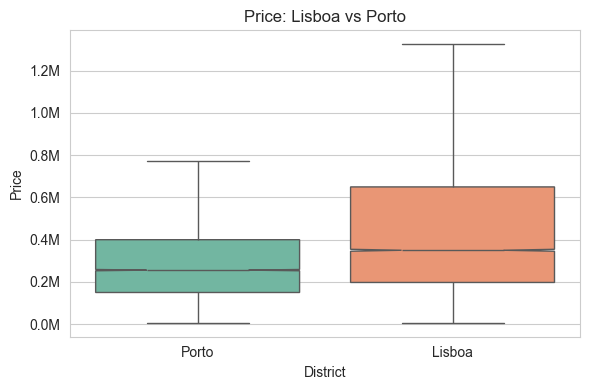

In [22]:
price_lisbon = df.loc[df["District"] == "Lisboa", "Price"]
price_porto = df.loc[df["District"] == "Porto", "Price"]

stat, pval = stats.mannwhitneyu(price_lisbon, price_porto, alternative="greater")

print(f"Median price (Lisboa): €{price_lisbon.median():,.0f}")
print(f"Median price (Porto):  €{price_porto.median():,.0f}")
print(f"Mann-Whitney U-test: U={stat:,.0f}, p={pval:.3e}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=df[df["District"].isin(["Lisboa", "Porto"])],
    x="District",
    y="Price",
    showfliers=False,
    hue="District",
    palette="Set2",
    legend=False,
    notch=True,
    ax=ax,
)
ax.set_title("Price: Lisboa vs Porto")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

Again our p value is well below our significance level, which means that we reject our Nullhypothesis and conclude the alternative one. The statistic significance gets supported by non overlapping confidence intervals, which we can see above.

### Hypothesis 3: Energy Certificate and Price

Nullhypothesis: There are no significant differences in price distributions - rank positions between the different energy certificate classes. \
Alternative Hypothesis: They do differ significantly. \
Significance Level: 0.05 \
Test: Kruskal-Wallis H-test

In [23]:
order_ec = ["A+", "A", "B", "B-", "C", "D", "E", "F", "G", "NC"]
valid_ec = [e for e in order_ec if e in df["EnergyCertificate"].unique()]
groups = [df.loc[df["EnergyCertificate"] == ec, "Price"].values for ec in valid_ec]

h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H={h_stat:.2f}, df={len(groups)-1}, p={p_kw:.3e}")

Kruskal-Wallis H-test: H=23381.08, df=9, p=0.000e+00


Our p-value is well below our significance level.
Now we know that the effect - the tendency is statistically significant, but we dont know in which way until now. 
This is why we are doing the Dunn-Bonferroni post-hoc test.

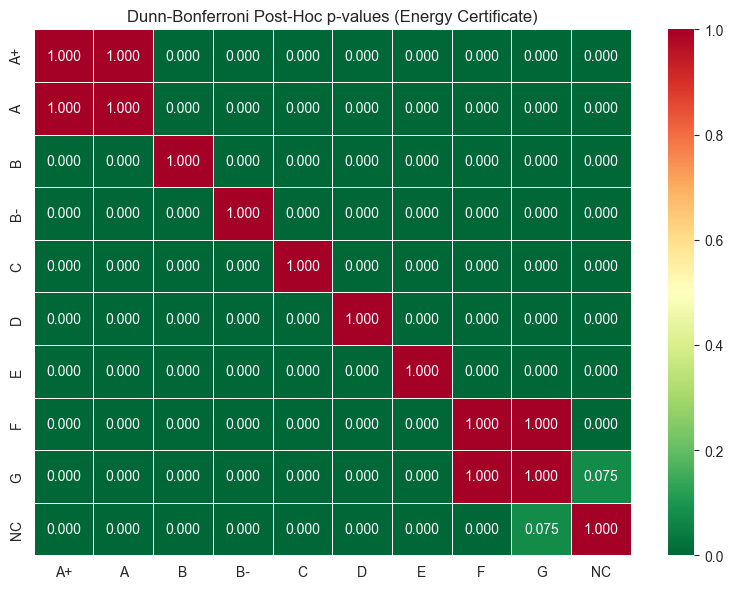

In [24]:
df_ec = df[df["EnergyCertificate"].isin(valid_ec)][
    ["Price", "EnergyCertificate"]
].copy()
dunn = posthoc_dunn(
    df_ec, val_col="Price", group_col="EnergyCertificate", p_adjust="bonferroni"
)
dunn = dunn.loc[valid_ec, valid_ec]

fig, ax = plt.subplots(figsize=(8, 6))
mask = dunn >= 0.05
sns.heatmap(
    dunn,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    mask=mask & False,
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=1,
)
ax.set_title("Dunn-Bonferroni Post-Hoc p-values (Energy Certificate)")
plt.tight_layout()
plt.show()

We see that almost all energy certificate classes differ significantly from each other (p = 0.000). The only exceptions are **A+ vs A** (p = 1.000), **F vs G** (p = 1.000), and **G vs NC** (p = 0.075) — these pairs do not differ significantly in their price distributions - rank positions. Combined with the median prices observed in our EDA (where A+ and A showed the highest prices, declining through B, C, D down to F and G), we can conclude that higher energy certificates are indeed associated with higher property prices. We therefore reject the null hypothesis.

### Statistical Inference Summary

All three hypotheses were tested using non-parametric methods due to the non-normal price distribution:

1. **Apartments vs Houses:** Significant price difference confirmed (Mann-Whitney U, p < 0.001).
2. **Lisboa vs Porto:** Lisboa prices are significantly higher (Mann-Whitney U, p < 0.001).
3. **Energy Certificate:** Significant price differences across classes (Kruskal-Wallis, p < 0.001). Post-hoc testing showed nearly all classes differ, except A+ vs A, F vs G, and G vs NC.

The EDA tendencies are all statistically significant — property type, location, and energy certification are meaningful price drivers.

## Modeling

This is a **regression** task — predicting continuous house prices. We use `log(Price)` as discussed above and use the following **Metrics:** 

`RMSE, MAE, R²`

At first we prepare our features and target, by log-transforming the target.

In [25]:
target = "Price"
drop_cols = ["Price"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target].copy()

print(f"Features: {list(X.columns)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features: ['District', 'Type', 'EnergyCertificate', 'TotalArea', 'Parking', 'ConstructionYear', 'Elevator', 'LivingArea', 'NumberOfBathrooms']
X shape: (100151, 9)
y shape: (100151,)


### Split the Data

We apply log transformation after the split to avoid data leakage.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

print(f"Training set: {len(X_train):,}")
print(f"Test set: {len(X_test):,}")

Training set: 80,120
Test set: 20,031


### Preprocessing

In [27]:
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                min_frequency=0.01,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features),
    ]
)

### Baseline models

In [28]:
baseline_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
}

baseline_results = []
fitted_models = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

for name, model in baseline_models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])

    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
    )

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    baseline_results.append(
        {
            "model": name,
            "cv_rmse": round(-scores["test_rmse"].mean(), 4),
            "cv_mae": round(-scores["test_mae"].mean(), 4),
            "cv_r2": round(scores["test_r2"].mean(), 4),
        }
    )

baseline_df = pd.DataFrame(baseline_results).set_index("model").sort_values("cv_rmse")
display(baseline_df)

,cv_rmse,cv_mae,cv_r2
model,,,
RandomForest,0.6367,0.4193,0.6592
KNN,0.6907,0.4747,0.5989
LinearRegression,0.7354,0.5310,0.5451
Ridge,0.7354,0.5310,0.5451
DecisionTree,0.7904,0.5126,0.4748
Lasso,1.0907,0.8565,-0.0000


### Light Hyperparameter Tuning

We test small hyperparameter ranges on all models using cross-validation. Our goal here is to find the best models from where we are going to fine-tune them using systematic search techniques.

In [29]:
light_grids = {
    "Ridge": {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]},
    "KNN": {
        "model__n_neighbors": [1, 3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["minkowski"],
        "model__p": [1, 2],
    },
    "DecisionTree": {
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_split": [2, 5, 10],
    },
    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None],
    },
}

light_results = []

for name, param_grid in light_grids.items():
    model = baseline_models[name]
    pipe = Pipeline([("prep", preprocessor), ("model", model)])

    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    fitted_models[name + "_Light"] = best

    scores = cross_validate(
        best, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
    )

    light_results.append(
        {
            "model": name,
            "best_params": grid.best_params_,
            "cv_rmse": round(-scores["test_rmse"].mean(), 4),
            "cv_mae": round(-scores["test_mae"].mean(), 4),
            "cv_r2": round(scores["test_r2"].mean(), 4),
        }
    )

light_df = pd.DataFrame(light_results).set_index("model").sort_values("cv_rmse")
display(light_df)

,best_params,cv_rmse,cv_mae,cv_r2
model,,,,
RandomForest,"{'model__max_depth': 20, 'model__n_estimators'...",0.6194,0.4184,0.6774
KNN,"{'model__metric': 'minkowski', 'model__n_neigh...",0.6623,0.4374,0.6312
DecisionTree,"{'model__max_depth': 20, 'model__min_samples_s...",0.6849,0.4663,0.6056
Ridge,{'model__alpha': 0.01},0.7354,0.5310,0.5451
Lasso,{'model__alpha': 0.0001},0.7355,0.5309,0.5451


### Advanced models (Gradient Boosting, XGBoost, LightGBM)

In [30]:
advanced_models = {
    "GradientBoosting": Pipeline(
        [
            ("prep", preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
                ),
            ),
        ]
    ),
    "XGBoost": Pipeline(
        [
            ("prep", preprocessor),
            (
                "model",
                XGBRegressor(
                    n_estimators=200,
                    max_depth=5,
                    learning_rate=0.1,
                    random_state=42,
                    n_jobs=-1,
                    verbosity=0,
                ),
            ),
        ]
    ),
    "LightGBM": Pipeline(
        [
            ("prep", preprocessor),
            (
                "model",
                LGBMRegressor(
                    n_estimators=200,
                    max_depth=5,
                    learning_rate=0.1,
                    random_state=42,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    ),
}

advanced_results = []

for name, pipe in advanced_models.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
    )

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    advanced_results.append(
        {
            "model": name,
            "cv_rmse": round(-scores["test_rmse"].mean(), 4),
            "cv_mae": round(-scores["test_mae"].mean(), 4),
            "cv_r2": round(scores["test_r2"].mean(), 4),
        }
    )

advanced_df = pd.DataFrame(advanced_results).set_index("model").sort_values("cv_rmse")
display(advanced_df)

,cv_rmse,cv_mae,cv_r2
model,,,
XGBoost,0.6325,0.4442,0.6637
GradientBoosting,0.6329,0.4449,0.6632
LightGBM,0.6333,0.4448,0.6629


### Tuning the Best Models

We fine-tune the top models. For **RandomForest** and **GradientBoosting** we use GridSearchCV; for **XGBoost** and **LightGBM** we use **Optuna** (Bayesian optimization) for more efficient search.

#### GridSearchCV: RandomForest & GradientBoosting

In [31]:
dense_grids = {
    "RandomForest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [15, 20],
        "model__min_samples_leaf": [1, 2],
    },
    "GradientBoosting": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [5, 7],
        "model__learning_rate": [0.05, 0.1],
    },
}

dense_results = []

for name, param_grid in dense_grids.items():
    if name == "GradientBoosting":
        pipe = Pipeline(
            [
                ("prep", preprocessor),
                ("model", GradientBoostingRegressor(random_state=42)),
            ]
        )
    else:
        pipe = Pipeline(
            [
                ("prep", preprocessor),
                ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
            ]
        )

    grid = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        refit=True,
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    best = grid.best_estimator_
    tuned_name = name + "_Tuned"
    fitted_models[tuned_name] = best

    scores = cross_validate(
        best, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
    )

    dense_results.append(
        {
            "model": tuned_name,
            "best_params": grid.best_params_,
            "cv_rmse": round(-scores["test_rmse"].mean(), 4),
            "cv_mae": round(-scores["test_mae"].mean(), 4),
            "cv_r2": round(scores["test_r2"].mean(), 4),
        }
    )

dense_df = pd.DataFrame(dense_results).set_index("model").sort_values("cv_rmse")
display(dense_df)

/Users/moe/.pyenv/versions/3.12.0/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,best_params,cv_rmse,cv_mae,cv_r2
model,,,,
GradientBoosting_Tuned,"{'model__learning_rate': 0.1, 'model__max_dept...",0.6182,0.4284,0.6787
RandomForest_Tuned,"{'model__max_depth': 20, 'model__min_samples_l...",0.6194,0.4183,0.6775


#### Optuna: XGBoost, LGBoost

In [32]:
optuna.logging.set_verbosity(optuna.logging.WARNING)


def make_xgb_objective(X_tr, y_tr, cv_folds):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        }
        pipe = Pipeline(
            [
                ("prep", preprocessor),
                (
                    "model",
                    XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0),
                ),
            ]
        )
        scores = cross_val_score(
            pipe,
            X_tr,
            y_tr,
            cv=cv_folds,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
        )
        return -scores.mean()

    return objective


def make_lgbm_objective(X_tr, y_tr, cv_folds):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        }
        pipe = Pipeline(
            [
                ("prep", preprocessor),
                (
                    "model",
                    LGBMRegressor(**params, random_state=42, n_jobs=-1, verbose=-1),
                ),
            ]
        )
        scores = cross_val_score(
            pipe,
            X_tr,
            y_tr,
            cv=cv_folds,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
        )
        return -scores.mean()

    return objective


optuna_results = []

for name, make_obj, ModelClass in [
    ("XGBoost", make_xgb_objective, XGBRegressor),
    ("LightGBM", make_lgbm_objective, LGBMRegressor),
]:
    study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(make_obj(X_train, y_train, cv), n_trials=50, show_progress_bar=True)

    best_params = study.best_params
    print(f"\n{name} best params: {best_params}")
    print(f"{name} best CV RMSE: {study.best_value:.4f}")

    if name == "XGBoost":
        best_pipe = Pipeline(
            [
                ("prep", preprocessor),
                (
                    "model",
                    XGBRegressor(
                        **best_params, random_state=42, n_jobs=-1, verbosity=0
                    ),
                ),
            ]
        )
    else:
        best_pipe = Pipeline(
            [
                ("prep", preprocessor),
                (
                    "model",
                    LGBMRegressor(
                        **best_params, random_state=42, n_jobs=-1, verbose=-1
                    ),
                ),
            ]
        )

    best_pipe.fit(X_train, y_train)
    tuned_name = name + "_Tuned"
    fitted_models[tuned_name] = best_pipe

    scores = cross_validate(
        best_pipe, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=-1
    )

    optuna_results.append(
        {
            "model": tuned_name,
            "best_params": best_params,
            "cv_rmse": round(-scores["test_rmse"].mean(), 4),
            "cv_mae": round(-scores["test_mae"].mean(), 4),
            "cv_r2": round(scores["test_r2"].mean(), 4),
        }
    )

optuna_df = pd.DataFrame(optuna_results).set_index("model").sort_values("cv_rmse")
display(optuna_df)

  0%|          | 0/50 [00:00<?, ?it/s]


XGBoost best params: {'n_estimators': 460, 'max_depth': 10, 'learning_rate': 0.03764329971391593, 'subsample': 0.9429961250794995, 'colsample_bytree': 0.7721370045125135, 'reg_alpha': 0.0011407317710955937, 'reg_lambda': 1.6885476286049659}
XGBoost best CV RMSE: 0.6078


  0%|          | 0/50 [00:00<?, ?it/s]


LightGBM best params: {'n_estimators': 469, 'max_depth': 10, 'learning_rate': 0.0695549134793727, 'subsample': 0.6069764982585817, 'colsample_bytree': 0.6616143931155649, 'reg_alpha': 0.007112376531387731, 'reg_lambda': 0.17852376747319024, 'num_leaves': 145}
LightGBM best CV RMSE: 0.6109


,best_params,cv_rmse,cv_mae,cv_r2
model,,,,
XGBoost_Tuned,"{'n_estimators': 460, 'max_depth': 10, 'learni...",0.6078,0.4157,0.6895
LightGBM_Tuned,"{'n_estimators': 469, 'max_depth': 10, 'learni...",0.6109,0.4202,0.6863


### Ensemble

Now we take the best models from our top models so far and combine them. We combine the best Boosting (XGBoost), Bagging (RandomForest) and instance-based (KNN) model to maximize diversity in the ensemble.

In [33]:
ensemble = VotingRegressor(
    estimators=[
        ("xgb", fitted_models.get("XGBoost_Tuned", fitted_models["XGBoost"])),
        ("rf", fitted_models.get("RandomForest_Tuned", fitted_models["RandomForest"])),
        ("knn", fitted_models.get("KNN_Light", fitted_models["KNN"])),
    ],
    n_jobs=-1,
)

cv_scores = cross_val_score(
    ensemble, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1
)
ensemble_cv_rmse = -cv_scores.mean()

ensemble.fit(X_train, y_train)
fitted_models["Ensemble_Voting"] = ensemble

y_pred_ensemble = ensemble.predict(X_test)
ensemble_test_rmse = round(np.sqrt(mean_squared_error(y_test, y_pred_ensemble)), 4)
ensemble_test_mae = round(mean_absolute_error(y_test, y_pred_ensemble), 4)
ensemble_test_r2 = round(r2_score(y_test, y_pred_ensemble), 4)

print(
    f"Ensemble_Voting  CV RMSE: {ensemble_cv_rmse:.4f}  Test RMSE: {ensemble_test_rmse:.4f}  MAE: {ensemble_test_mae:.4f}  R²: {ensemble_test_r2:.4f}"
)

Ensemble_Voting  CV RMSE: 0.6062  Test RMSE: 0.6023  MAE: 0.4054  R²: 0.6951


### Final comparison

Finally we take a look on how all the models trained, perform on the hold-out test set.

In [34]:
final_results = []

key_models = [
    "LinearRegression",
    "Ridge",
    "RandomForest",
    "GradientBoosting",
    "XGBoost",
    "LightGBM",
    "RandomForest_Tuned",
    "GradientBoosting_Tuned",
    "XGBoost_Tuned",
    "LightGBM_Tuned",
    "Ensemble_Voting",
]

for name in key_models:
    if name not in fitted_models:
        continue
    model = fitted_models[name]
    y_pred = model.predict(X_test)

    final_results.append(
        {
            "model": name,
            "test_rmse": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
            "test_mae": round(mean_absolute_error(y_test, y_pred), 4),
            "test_r2": round(r2_score(y_test, y_pred), 4),
        }
    )

final_df = pd.DataFrame(final_results).set_index("model").sort_values("test_rmse")
display(final_df)

,test_rmse,test_mae,test_r2
model,,,
Ensemble_Voting,0.6023,0.4054,0.6951
XGBoost_Tuned,0.6056,0.4169,0.6917
LightGBM_Tuned,0.6109,0.4222,0.6864
GradientBoosting_Tuned,0.6165,0.4302,0.6806
RandomForest_Tuned,0.6182,0.4167,0.6788
GradientBoosting,0.6342,0.4483,0.6619
RandomForest,0.6354,0.4152,0.6606
XGBoost,0.6355,0.4486,0.6606
LightGBM,0.6366,0.4488,0.6594


### Feature importance

We show two views: **per encoded feature** (where each one-hot-encoded district/type gets its own bar) and **aggregated** (where all categories of a feature are summed back into the original feature name). The aggregated view is more useful for understanding which *concepts* or original features matter most.

Best model: Ensemble_Voting
(Using sub-estimator 'xgb' for feature importance & SHAP)


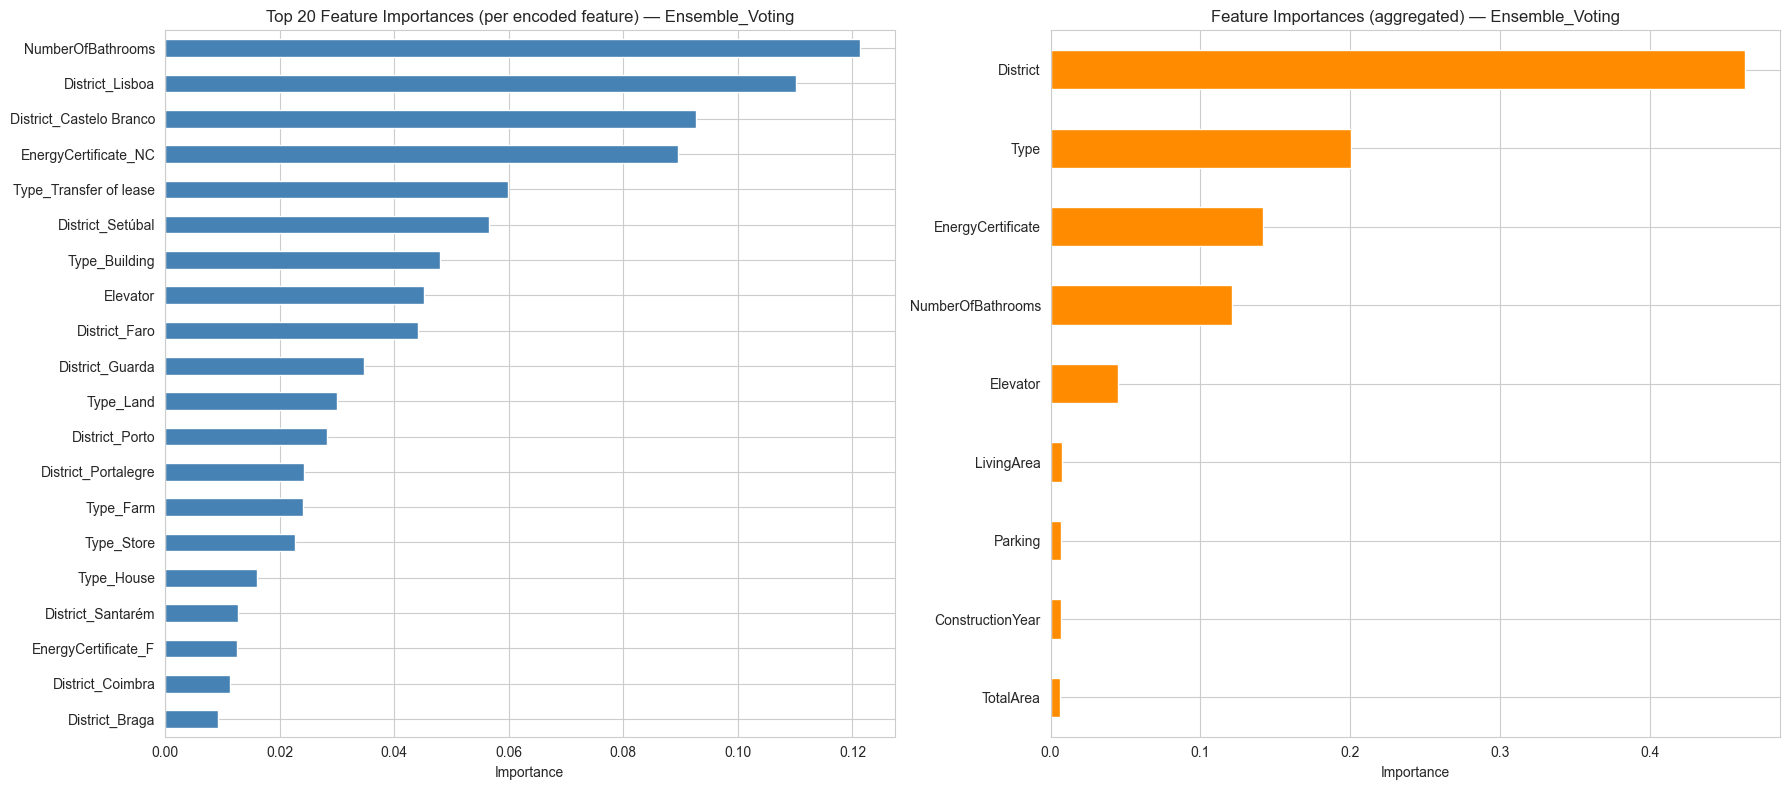

In [35]:
best_model_name = final_df.index[0]
best_model = fitted_models[best_model_name]
print(f"Best model: {best_model_name}")

if hasattr(best_model, "estimators_"):
    interpret_model = best_model.estimators_[0]
    print(f"(Using sub-estimator '{best_model.estimators[0][0]}' for feature importance & SHAP)")
else:
    interpret_model = best_model

prep = interpret_model.named_steps["prep"]
ohe = prep.named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names
inner_model = interpret_model.named_steps["model"]
importances = inner_model.feature_importances_

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

# Aggregate OHE features back to original categorical feature names
original_names = [
    next((cat for cat in cat_features if name.startswith(cat + "_")), name)
    for name in all_feature_names
]
feat_imp_agg = (
    pd.Series(importances, index=original_names)
    .groupby(level=0).sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

feat_imp.head(20).sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title(f"Top 20 Feature Importances (per encoded feature) — {best_model_name}")
axes[0].set_xlabel("Importance")

feat_imp_agg.sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title(f"Feature Importances (aggregated) — {best_model_name}")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

**Observations:** District is by far the most important feature — location dominates price prediction. Type (house vs. apartment) ranks second. Among numeric features, EnergyCertificate, NumberOfBathrooms, and LivingArea contribute meaningfully, while Parking, ConstructionYear, and TotalArea have less individual impact.

However, feature importance has a limitation: it tells us *how much* a feature matters but not *how* it affects the prediction - does a higher value push the price up or down? 

That's why we are taking a look at SHAP in the next step.

### SHAP Explainability

**SHAP** goes beyond feature importance by showing *how* each feature pushes a prediction up or down. For every single prediction, SHAP assigns each feature a contribution value: positive means it pushed the predicted price higher, negative means lower. This is grounded in game theory — each feature's contribution is calculated as its fair share of the prediction, accounting for interactions with all other features.

100%|===================| 19993/20031 [07:15<00:00]        

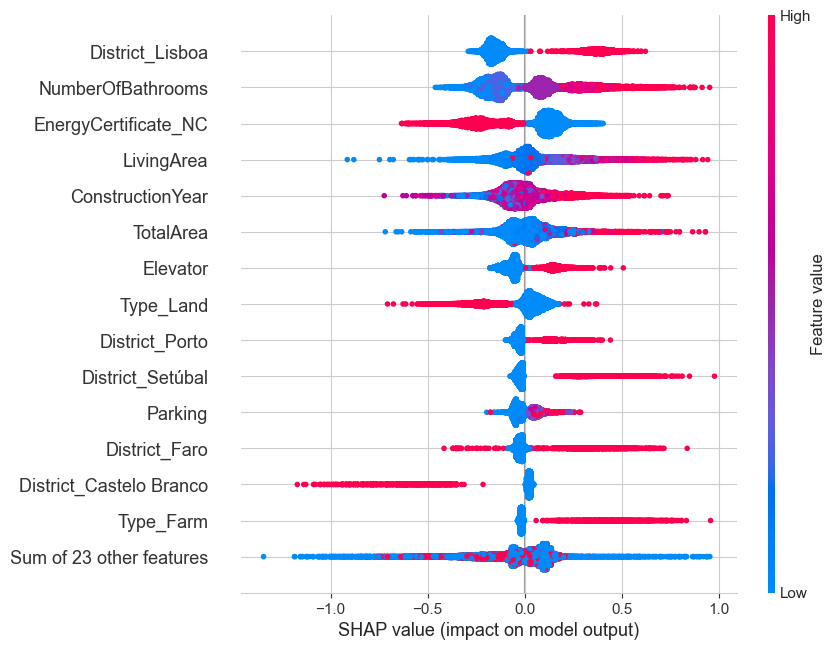

In [36]:
X_test_transformed = prep.transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

explainer = shap.Explainer(inner_model, X_test_df)
shap_values = explainer(X_test_df)
shap.plots.beeswarm(shap_values, max_display=15, show=True)

**Observations:**

- **District_Lisboa** is the most impactful feature. Red dots (= property *is* in Lisboa) cluster on the right (positive SHAP), meaning being in Lisboa strongly pushes prices up. Blue dots (= not in Lisboa) pull prices down. This confirms location as the dominant price driver.
- **NumberOfBathrooms** — higher values (red) push prices up, lower values (blue) push down. More bathrooms signal larger, higher-end properties.
- **EnergyCertificate_NC** (no certificate) — having no energy certificate (red = 1) pushes prices down, consistent with these being older or less well-maintained properties.
- **LivingArea** and **TotalArea** — higher values push prices up, as expected. The spread of SHAP values is wide, meaning area has a large effect for extreme values (very large or very small properties).
- **ConstructionYear** — newer properties (red/high year) tend to push prices up slightly.
- **Elevator** — having an elevator (red = 1) pushes prices up, likely proxying for multi-story urban apartment buildings in desirable areas.

Overall, the SHAP analysis aligns with our EDA findings: location and size drive prices, with property characteristics (type, energy cert, elevator) playing supporting roles.

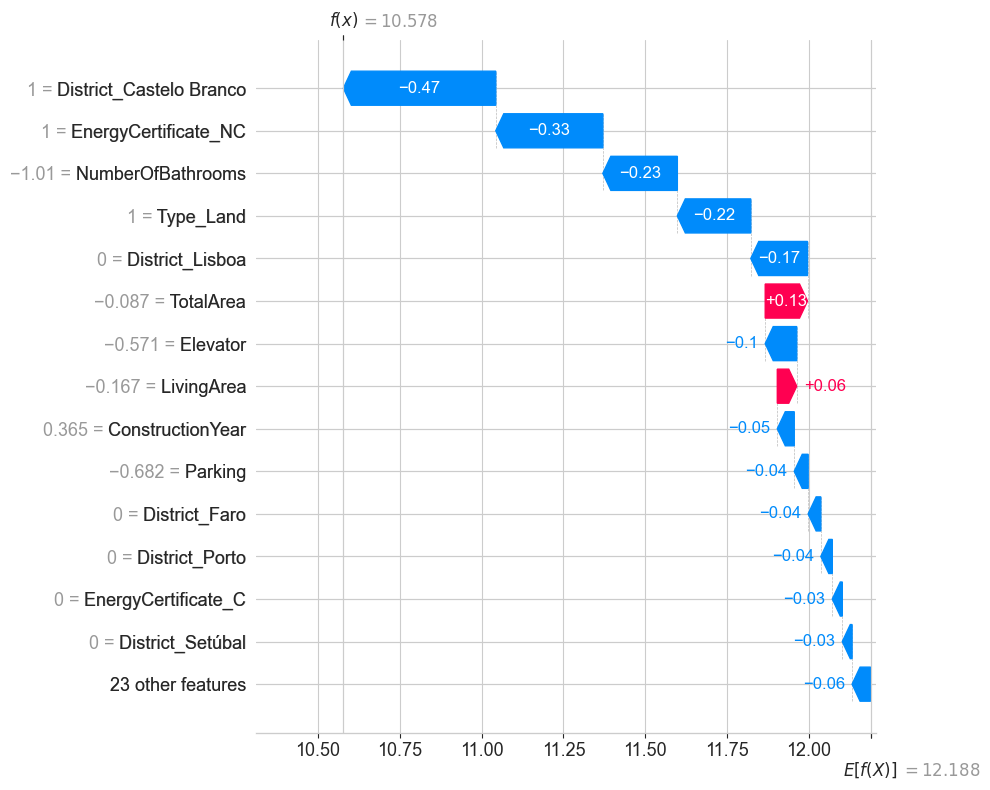

In [37]:
shap.plots.waterfall(shap_values[0], max_display=15, show=True)

This shows how the model arrived at its prediction for **one specific property**. Starting from the average predicted log-price (the base value, ~12.17), each bar shows a feature pushing the prediction up (red) or down (blue).

The final prediction lands at f(x) = ~10.58 in log-space. This kind of per-prediction breakdown is what makes the model interpretable for end users — instead of just outputting a price, we can explain *why* the model predicted that price for a specific property.

### Sample prediction

In [38]:
sample_idx = X_test.sample(n=1, random_state=42).index[0]
sample_X = X_test.loc[[sample_idx]]
sample_y_true = y_test.loc[sample_idx]

print("Sample property profile:")
print(sample_X.T)
print()

y_pred_log = best_model.predict(sample_X)[0]
y_pred_price = np.expm1(y_pred_log)
y_true_price = np.expm1(sample_y_true)

print(f"Best model: {best_model_name}")
print(f"Predicted price: €{y_pred_price:,.0f}")
print(f"Actual price:    €{y_true_price:,.0f}")
print(
    f"Error:           €{abs(y_pred_price - y_true_price):,.0f} ({abs(y_pred_price - y_true_price)/y_true_price*100:.1f}%)"
)

Sample property profile:
                    42830
District           Leiria
Type                House
EnergyCertificate       D
TotalArea           167.0
Parking               2.0
ConstructionYear   2010.0
Elevator              0.0
LivingArea          167.0
NumberOfBathrooms     3.0

Best model: Ensemble_Voting
Predicted price: €303,640
Actual price:    €380,000
Error:           €76,360 (20.1%)


### Model Selection

In [39]:
print(f"Selected model: {best_model_name}")
print(f"\nTest set metrics:")
print(final_df.loc[best_model_name])

Selected model: Ensemble_Voting

Test set metrics:
test_rmse    0.6023
test_mae     0.4054
test_r2      0.6951
Name: Ensemble_Voting, dtype: float64


This model was selected because it achieves the lowest RMSE on the held-out test set,
indicating the best generalization to unseen data.

We choose RMSE as our primary metric because for house price prediction, big misses matter more than small ones — e.g. telling someone  
their house is worth €300k when it's actually €500k is much worse than being off by €10k on two properties.

## Model Serialization & Deployment

We serialize the best model and create a FastAPI application with Docker containerization for deployment to the Google Cloud Platform.

### Save the model

In [40]:
joblib.dump(best_model, "model/model.pkl", compress=3)
print(f"Model saved as model/model.pkl")

feature_info = {
    "num_features": num_features,
    "cat_features": cat_features,
    "all_columns": feature_cols,
}
joblib.dump(feature_info, "model/feature_info.pkl")
print(f"Feature info saved as model/feature_info.pkl")

Model saved as model/model.pkl
Feature info saved as model/feature_info.pkl


#### Example Curl for local testing

```bash
curl -X 'POST' \
  'http://127.0.0.1:8000/predict' \
  -H 'Content-Type: application/json' \
  -H 'X-API-Key: my-secret-key' \
  -d '{
  "District": "Lisboa",
  "Type": "Apartment",
  "EnergyCertificate": "B",
  "TotalArea": 100.0,
  "Parking": 1.0,
  "ConstructionYear": 2000.0,
  "Elevator": 0,
  "LivingArea": 80.0,
  "NumberOfBathrooms": 2.0
}'
```

#### Gcloud deployment testing

```bash
curl -X POST https://realestate-api-826068099925.europe-west1.run.app/predict \
  -H "Content-Type: application/json" \
  -H "X-API-Key: my-secret-key" \
  -d '{"District":"Lisboa",
  "Type":"Apartment",
  "EnergyCertificate":"B",
  "TotalArea":100,
  "Parking":1,
  "ConstructionYear":2000,
  "Elevator":0,
  "LivingArea":80,
  "NumberOfBathrooms":2
}'
```

## Conclusion

### Summary of Findings

**EDA:** Price is heavily right-skewed with significant outliers. Location (District), property type, and energy certificate are the key categorical drivers, while NumberOfBathrooms and LivingArea are the strongest numeric predictors.

**Statistical Inference:** All three hypotheses confirmed statistically significant relationships — apartments vs houses differ in price, Lisboa is more expensive than Porto, and energy certificate class is associated with price level. Non-parametric tests were used throughout due to non-normal price distributions.

**Modeling:** XGBoost (tuned) achieved the best performance on the test set (RMSE: 0.606, MAE: 0.417, R²: 0.692 on log-price). SHAP analysis confirmed that District (especially Lisboa) is the dominant price driver, followed by property type and energy certificate.

**Deployment:** The final model was serialized and deployed as a FastAPI application via Docker on Google Cloud Run, providing a REST endpoint for real-time price predictions.

### Limitations and Improvements

- We had to drop a large number of features due to high missing rates (>50%), including energy efficiency level, number of bedrooms, and total rooms — losing potentially useful predictive information.
- The model was trained on a snapshot of the market — retraining on updated data would be needed to keep predictions current.
- No feature engineering was performed — creating derived features such as price per m², building age (current year minus construction year), or other interactions could improve model performance.
- While we explored a wide range of models (linear, KNN, tree-based, boosting, ensemble), neural networks, stacking ensembles or other models could potentially capture more complex patterns in the data.
- Build specific models for regions/groups - also concerning the task description "house".